# A Mixture-of-Experts Framework for Hybrid-Quantum Fraud Detection — a guided reproduction

**Paper**: *A Mixture-of-Experts Framework for Practical Hybrid-Quantum Models in Credit Card Fraud Detection* ([arXiv:2603.06473](https://arxiv.org/abs/2603.06473))

This notebook walks through the reproduction step by step: what the paper proposes, how each
component works, a small end-to-end run you can execute in a few minutes on CPU, and then the
full statistically-powered findings loaded from the curated `results/` directory.

**Requirements**: `pip install -r requirements.txt`, plus the dataset at
`../../data/MoE_fraud_detection/creditcard.csv` (fetched once via
`sklearn.datasets.fetch_openml(data_id=1597)` — see the README's Data section).
Total runtime of this notebook: roughly 2–4 minutes.

**The idea in one paragraph.** Credit-card fraud detection is extremely imbalanced
(~0.17% positives), and the paper's premise is that a quantum-hybrid classifier is too slow to
run on every transaction — so it builds a *mixture of experts*: a fast XGBoost model handles
almost all traffic, and a learned *router* forwards only the hard ~1–3% of transactions to a
quantum-hybrid "second opinion" (an autoencoder-compressed variational quantum circuit).
The claim under test is that this routing improves AUCPR over plain XGBoost.

In [1]:
# Setup: make the paper's lib/ importable and keep the notebook reproducible.
import sys
from pathlib import Path

REPO_ROOT = Path.cwd().resolve().parents[1]  # papers/MoE_fraud_detection -> repo root
sys.path.insert(0, str(REPO_ROOT))

import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

np.random.seed(42)
print("repo root:", REPO_ROOT)

repo root: C:\Users\BenjaminSTOTT\PycharmProjects\reproduction_docker\reproduced_papers


## 1. The data: 284,807 transactions, 492 frauds

The ULB European credit-card dataset: 29 anonymized PCA features plus `Amount`, and a highly
imbalanced binary label. Chance-level AUCPR equals the positive rate (~0.0017), which is why
the paper evaluates with AUCPR/AP rather than accuracy or ROC-AUC — a classifier that predicts
"legitimate" for everything is 99.8% accurate and completely useless.

284,807 transactions x 29 features, 492 frauds (0.173%)


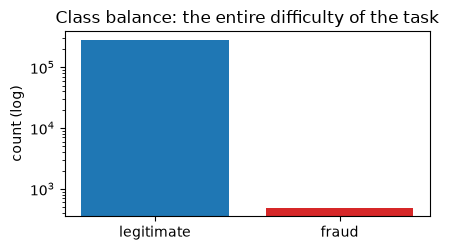

In [2]:
from lib.data import load_raw_data

X, y, feature_names = load_raw_data()
pos = int(y.sum())
print(f"{X.shape[0]:,} transactions x {X.shape[1]} features, "
      f"{pos} frauds ({100 * pos / len(y):.3f}%)")

fig, ax = plt.subplots(figsize=(4.5, 2.6))
ax.bar(["legitimate", "fraud"], [len(y) - pos, pos], color=["#1f77b4", "#d62728"])
ax.set_yscale("log")
ax.set_ylabel("count (log)")
ax.set_title("Class balance: the entire difficulty of the task")
plt.tight_layout()
plt.show()

## 2. The "Guided Quantum Compressor" (GQC): the quantum-hybrid expert

The secondary expert is a four-stage pipeline (paper Fig. 1):

1. **Autoencoder** (trained on *non-fraud* rows only): compresses the 29 features to a
   6-dimensional latent code — chosen to match the number of qubits. Its reconstruction error
   also acts as an implicit novelty signal, since fraud reconstructs poorly.
2. **Variational quantum circuit**: the 6 latents are angle-encoded into a 6-qubit
   Alternating Layered Ansatz (6 layers); the readout is the Pauli-Z expectation on qubit 0.
3. **Classical head**: a small FNN maps that single expectation to a fraud logit.
4. **Temperature calibration** (Platt scaling) on the validation split, so the expert's
   probabilities are comparable with XGBoost's when the router mixes them.

This reproduction implements the VQC in three interchangeable backends behind one interface —
`gate` (PennyLane, paper-accurate), `photonic` (MerLin linear optics, 6 modes / 3 photons),
and `classical` (a parameter-matched dense layer, the fair-ablation control that tells us
whether anything quantum matters at all).

In [3]:
from lib.gqc_model import GQCModel

cfg_demo = {"model": {"backend": "gate", "n_qubits": 6,
                      "autoencoder": {"hidden_dims": [256, 128, 64]},
                      "vqc": {"n_layers": 6}, "head": {"hidden_dim": 8}}}
gqc = GQCModel(input_dim=29, cfg=cfg_demo)
n_params = sum(p.numel() for p in gqc.parameters())
vqc_params = sum(p.numel() for p in gqc.vqc.parameters())
print(gqc)
print(f"\ntotal trainable parameters: {n_params:,} (VQC itself: only {vqc_params})")

GQCModel(
  (encoder): Encoder(
    (net): Sequential(
      (0): Linear(in_features=29, out_features=256, bias=True)
      (1): ReLU()
      (2): Linear(in_features=256, out_features=128, bias=True)
      (3): ReLU()
      (4): Linear(in_features=128, out_features=64, bias=True)
      (5): ReLU()
      (6): Linear(in_features=64, out_features=6, bias=True)
    )
  )
  (decoder): Decoder(
    (net): Sequential(
      (0): Linear(in_features=6, out_features=64, bias=True)
      (1): ReLU()
      (2): Linear(in_features=64, out_features=128, bias=True)
      (3): ReLU()
      (4): Linear(in_features=128, out_features=256, bias=True)
      (5): ReLU()
      (6): Linear(in_features=256, out_features=29, bias=True)
    )
  )
  (vqc): VQCLayer(
    (torch_layer): <Quantum Torch Layer: func=circuit>
  )
  (head): Head(
    (net): Sequential(
      (0): Linear(in_features=1, out_features=8, bias=True)
      (1): ReLU()
      (2): Linear(in_features=8, out_features=1, bias=True)
      (3): Sigm

Note the proportions: the quantum circuit holds a few dozen parameters inside a
~100k-parameter classical pipeline. Whatever the verdict, it hinges on what those few
parameters contribute — which is exactly what the classical ablation isolates.

## 3. The mixture-of-experts router

Both experts emit calibrated fraud probabilities. The router is a third XGBoost model trained
to predict *where the quantum-hybrid expert corrects the primary's mistakes*:

- Per-expert decision thresholds τ₁, τ₂ are chosen on the validation split by maximizing
  **Youden's J = TPR − FPR** (`lib/moe.py::youden_j_threshold`).
- On the analysis split, each transaction gets a binary router target: 1 where expert 2 is
  right and expert 1 is wrong (Eq. 15) — "here the second opinion helps".
- At test time, transactions whose router score exceeds a threshold **γ** take the
  quantum-hybrid probability; the rest keep XGBoost's (Eq. 16). Higher γ → fewer routed.

A subtle bug lived in the τ selection: scikit-learn's `roc_curve` prepends a synthetic
`inf` threshold, and on folds where no real threshold achieves positive J, a bare argmax
selected it — silently making the expert "reject everything" for that fold's router targets.
It is fixed (argmax restricted to finite thresholds, regression-tested), and the saved
per-fold τ values bound its influence to ≤3 of 100 folds per config with no verdict change.

In [4]:
from lib.moe import build_router_targets, combine_predictions, youden_j_threshold

# Toy demonstration: expert 2 corrects expert 1 on exactly one sample.
y_true = np.array([0, 0, 1, 1, 1, 0])
p1 = np.array([0.1, 0.2, 0.9, 0.3, 0.8, 0.4])   # primary: misses sample 3
p2 = np.array([0.2, 0.1, 0.8, 0.9, 0.7, 0.3])   # secondary: catches it
tau1, tau2 = 0.5, 0.5
targets = build_router_targets(p1, y_true, p2, tau1, tau2, y_true)
print("router targets (1 = route to quantum expert):", targets)

router_scores = np.array([0.1, 0.0, 0.2, 0.9, 0.1, 0.0])
for gamma in (0.5, 0.95):
    mixed = combine_predictions(p1, p2, router_scores, gamma)
    print(f"gamma={gamma}: mixed probabilities {np.round(mixed, 2)}")

# The fixed edge case: anti-correlated scores have no positive-J threshold.
tau = youden_j_threshold(np.array([0.9, 0.8, 0.2, 0.1]), np.array([0, 0, 1, 1]))
print(f"worst-case Youden threshold is now finite: {tau}")

router targets (1 = route to quantum expert): [0 0 0 1 0 0]
gamma=0.5: mixed probabilities [0.1 0.2 0.9 0.9 0.8 0.4]
gamma=0.95: mixed probabilities [0.1 0.2 0.9 0.3 0.8 0.4]
worst-case Youden threshold is now finite: 0.1


## 4. A miniature end-to-end run

One CV split at smoke scale (3 training epochs) — **not** paper-accurate, but it exercises the
entire machinery: fold construction with the paper's train/validation/analysis/holdout
structure, both experts, calibration, router training, and the γ sweep. Takes ~30–60 s on CPU.

In [5]:
from runtime_lib.config import load_config
from runtime_lib.dtypes import resolve_config_dtypes
from lib.data import load_cv_splits
from lib.pipeline import _run_single_split

cfg = resolve_config_dtypes(load_config(Path("configs/smoke.json")))
splits = load_cv_splits(cfg)
print(f"{len(splits)} split; train={splits[0]['X_train'].shape[0]} (balanced), "
      f"holdout={splits[0]['X_holdout'].shape[0]} (natural imbalance)")

result = _run_single_split(cfg, splits[0], seed=42)
rows = [("XGBoost baseline", result["xgboost_baseline"]["aucpr"], "-")]
rows += [(f"MoE, gamma={g}", v["aucpr"], f"{v['routed_fraction']:.1%}")
         for g, v in result["thresholds"].items()]
print(pd.DataFrame(rows, columns=["model", "holdout AUCPR", "routed"]).to_string(index=False))

1 split; train=786 (balanced), holdout=14241 (natural imbalance)


           model  holdout AUCPR routed
XGBoost baseline       0.785676      -
  MoE, gamma=0.5       0.756468   4.9%
  MoE, gamma=0.7       0.756214   4.2%
  MoE, gamma=0.9       0.755533   3.1%


A single smoke split proves the plumbing, not the science — per-fold AUCPR on this
dataset swings by ±0.1 between folds, which is exactly why the real analysis needs a hundred
of them.

## 5. The powered findings (n = 100 CV folds)

Six configurations were each run over 20×5-fold CV: the gate model (three variants: default,
tuned-XGBoost baseline, validation-split router), the parameter-matched classical ablation,
and two photonic variants (fixed `LexGrouping` readout, trainable readout). The curated
per-fold statistics live in `results/analysis_*.json` — loaded below, no re-run needed.

In [6]:
configs = ["gate_powered", "gate_tuned_xgboost_powered", "gate_validation_router_powered",
           "classical_powered", "photonic_fixed_powered", "photonic_trainable_powered"]
rows = []
for name in configs:
    a = json.loads(Path(f"results/analysis_{name}.json").read_text())
    s = a["per_threshold"]["0.5"]
    rows.append({
        "config": name.replace("_powered", ""),
        "mean diff (g=0.5)": round(s["mean_diff"], 4),
        "95% CI": f"[{s['ci95'][0]:+.3f}, {s['ci95'][1]:+.3f}]",
        "paired-t p": round(s["paired_t_p"], 4),
        "fold win-rate": f"{s['win_rate']:.0%}",
        "median diff": round(s["median_diff"], 4),
        "worst fold": round(s["worst_fold_diff"], 3),
    })
pd.DataFrame(rows)

,config,mean diff (g=0.5),95% CI,paired-t p,fold win-rate,median diff,worst fold
0,gate,-0.0167,"[-0.028, -0.006]",0.0040,63%,0.0006,-0.284
1,gate_tuned_xgboost,-0.0247,"[-0.039, -0.010]",0.0010,54%,0.0001,-0.489
2,gate_validation_router,-0.0142,"[-0.026, -0.002]",0.0238,66%,0.0011,-0.413
3,classical,-0.0155,"[-0.027, -0.004]",0.0086,55%,0.0001,-0.281
4,photonic_fixed,-0.0195,"[-0.034, -0.005]",0.0096,57%,0.0004,-0.423
5,photonic_trainable,-0.0601,"[-0.082, -0.038]",0.0000,45%,-0.0011,-0.388


Read that table as one finding with two faces: **every mean difference is negative and
significant** (MoE loses to its own XGBoost baseline), yet **most folds favor MoE** and the
medians sit at zero. Both are true because the distribution is left-skewed — a ~5–11% minority
of folds suffers catastrophic collapse (the calibration of the secondary expert saturates on
tiny, near-separable validation folds), dragging the mean far below the median:

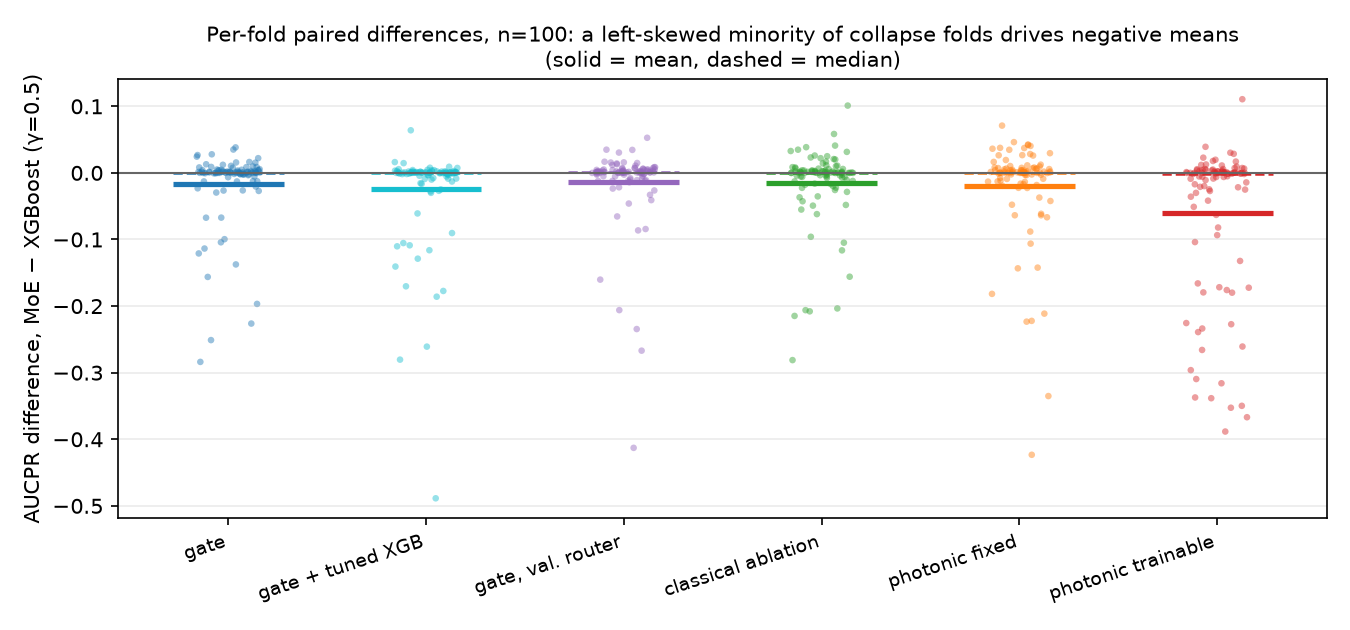

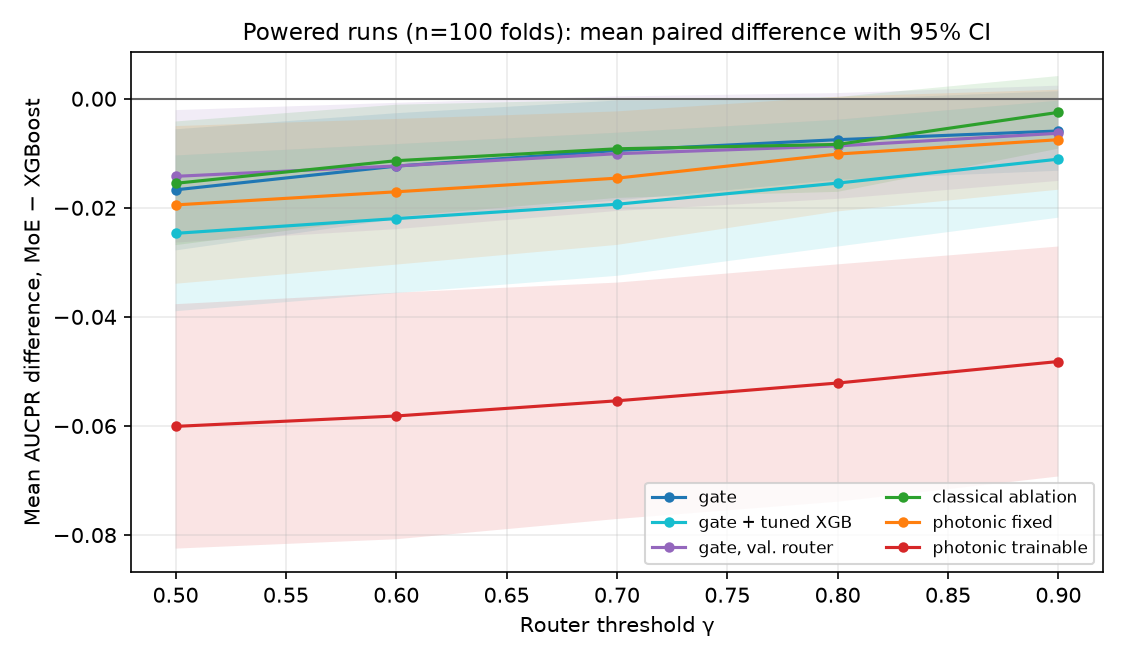

In [7]:
from IPython.display import Image, display
display(Image("results/fig_fold_diff_distribution.png"))
display(Image("results/fig_mean_diff_vs_gamma.png"))

Three take-aways, in decreasing order of certainty:

1. **The MoE construction does not beat plain XGBoost here.** The negative mean shrinks as γ
   rises (fewer transactions routed) — routing less to the secondary expert always helps,
   which is damning for the premise.
2. **The quantum block is not the differentiator.** The parameter-matched classical ablation
   behaves statistically like the gate model — the problem (and any future fix) lives in the
   MoE/calibration construction, not in anything quantum.
3. **The photonic variants don't rescue it** — the trainable-readout photonic model is the
   *worst* performer (mean −0.060, p<0.001 at every γ), reversing the initial hypothesis that
   a trainable readout would close the photonic-vs-gate gap.

Standing caveats: our absolute baseline sits ~0.08 AUCPR below the paper's (partly explained
by paper-unspecified XGBoost capacity), and several training hyper-parameters had to be chosen
by us. The verdict is about *this protocol faithfully implementing the paper's description*.

## 6. The latency claim (Table 1)

The paper motivates the whole MoE design with inference speed: its Table 1 reports the GQC
542–1387× faster than the QMKL/Genetic-Feature-Map alternatives. The *ranking* reproduces;
the *magnitude* does not (3–10× measured here, CPU-only, same protocol for all three):

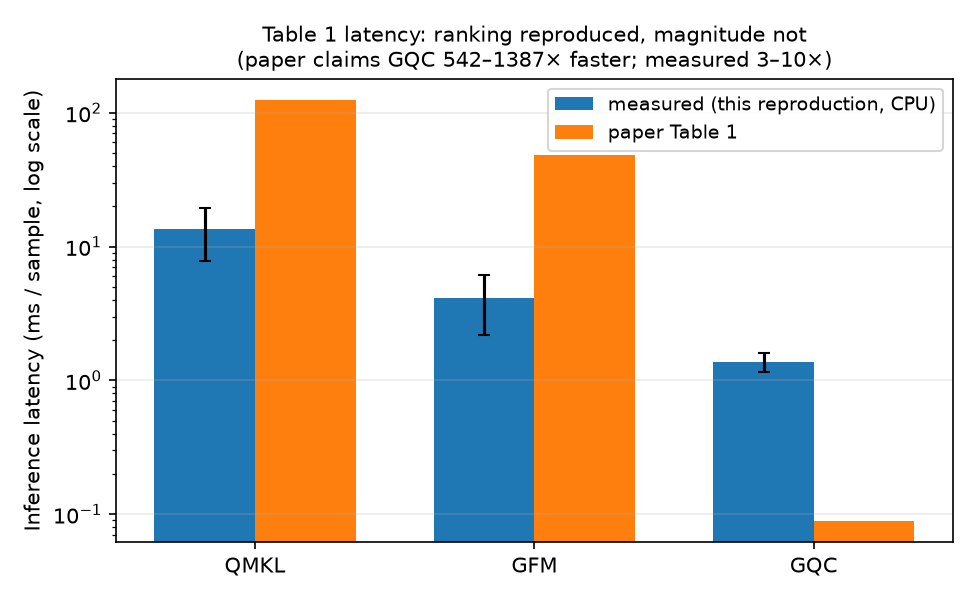

      ms_per_sample  cv_pct  std_ms_per_sample
QMKL          13.60   42.64               5.80
GFM            4.13   47.36               1.96
GQC            1.38   16.00               0.22


In [8]:
display(Image("results/fig_latency.png"))
print(pd.read_json("results/latency_benchmark.json").T.round(2).to_string())

## 7. Conclusions

- **Reproduced qualitatively**: precision/recall trade-off direction, routing fractions
  (~1–3%), latency ranking.
- **Not reproduced**: the headline MoE-beats-XGBoost claim (significantly negative at n=100,
  across gate, classical, and photonic backends) and the latency magnitude.
- **Diagnosed along the way**: a calibration-instability mechanism behind rare catastrophic
  folds (mitigated), and a router-threshold bug (fixed, regression-tested, and bounded to
  ≤0.003 AUCPR influence — no verdict changes).
- **Photonic feasibility**: the MerLin adaptation trains end-to-end and matches the gate model
  with a fixed readout; making the readout trainable *hurts*.

For the full detail: `README.md` (results tables and figures), `results/README.md`
(curated-artifact index and regeneration commands), and the per-config statistics in
`results/analysis_*.json`.